## 01 — EDA Behavior Analysis

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [184]:
PALETTE  = 'muted'
FIG_SIZE = (12, 5)
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.05)
FIGURES_PATH = '../outputs/figures/'

In [185]:
df = pd.read_csv('../data/raw/ecom_shop.csv', parse_dates=['timestamp'])

In [186]:
df['hour']       = df['timestamp'].dt.hour
df['dayofweek']  = df['timestamp'].dt.dayofweek   # 0 = Monday
df['dayname']    = df['timestamp'].dt.day_name()
df['date']       = df['timestamp'].dt.date

#### 4.1 Validate and exclude `session_start`

In [187]:
ss = df[df['event'] == 'session_start']

total_sessions = df['session_id'].nunique()
sessions_with_ss = ss['session_id'].nunique()

print(f"Session_start rows: {len(ss):,}")
print(f"Always at event_order=0: {(ss['event_order'] == 0).mean()*100:.1f}%")
print(f"Sessions with it: {sessions_with_ss:,} / {total_sessions:,} ({sessions_with_ss/total_sessions*100:.1f}%)")

Session_start rows: 115,953
Always at event_order=0: 100.0%
Sessions with it: 115,865 / 116,092 (99.8%)


`session_start` appears in 115,953 rows and is present in 99.8% of sessions
(115,865 out of 116,092). It occurs exclusively at `event_order = 0` in 100%
of cases, confirming it is a technical session delimiter, not a user action.

The remaining 0.2% of sessions (227) that lack `session_start` likely correspond
to incomplete session captures and are kept in the analysis — their first recorded
event is treated as the initial state.

`session_start` is excluded from the Markov state space. Including it would add
no behavioral information and would force every chain to begin with the same
trivial transition `session_start → X`.

#### 4.2 Rare event analysis and grouping

Events with very low frequency produce unreliable transition probability
estimates in the Markov matrix. We identify them and group them into a
single `other` state before building sequences.

Two criteria to keep an event as its own state:
- Frequency > 500 occurrences (minimum statistical mass)
- OR last_ratio > 0.15 (relevant as a terminal/absorbing state)

In [188]:
event_freq = df['event'].value_counts()

last_events = (
    df[df['event'] != 'session_start']
    .sort_values(['session_id', 'timestamp'])
    .groupby('session_id')['event']
    .last()
    .value_counts()
)

summary = pd.DataFrame({
    'freq'      : event_freq,
    'last_freq' : last_events
}).fillna(0).astype({'last_freq': int})

summary['last_ratio'] = (summary['last_freq'] / summary['freq']).round(3)
summary = summary.sort_values('freq')

display(summary)

,freq,last_freq,last_ratio
event,,,
view_item_list,9,1,0.111
reset_password_page,64,5,0.078
review_order,223,21,0.094
store_item_page,245,3,0.012
forgot_password_page,253,24,0.095
registration_page,327,37,0.113
wishlist_page,344,18,0.052
purchase,1182,832,0.704
registration,1801,39,0.022


In [189]:
RARE_EVENTS = {
    'view_item_list', 'reset_password_page', 'review_order', 'store_item_page', 'forgot_password_page', 'registration_page',
    'wishlist_page'}

df['event_clean'] = df['event'].apply(
    lambda e: 'other' if e in RARE_EVENTS else e
)

#### 4.3 Build clean event sequences

- Sort by `timestamp` within each `session_id`
- Exclude `session_start` — it is a technical delimiter, not a behavioral state
- Keep only sessions with ≥ 2 events (minimum for a transition)

In [190]:
EXCLUDE_EVENTS = {'session_start'}

df_seq = (
    df[~df['event_clean'].isin(EXCLUDE_EVENTS)]
    .sort_values(['session_id', 'timestamp'])
    .copy()
)

# Sequence per session
sequences = (
    df_seq.groupby('session_id')['event_clean']
    .apply(list)
    .reset_index()
    .rename(columns={'event_clean': 'event_sequence'})
)
sequences['seq_length'] = sequences['event_sequence'].str.len()

meta = df_seq.groupby('session_id').agg(
    is_old   = ('is_old_user', 'first'),
    category = ('category','first'),
    source   = ('source','first'),
    country  = ('country','first'),
).reset_index()

sequences = sequences.merge(meta, on='session_id')

sequences_valid = sequences[sequences['seq_length'] >= 2].copy()

#### 4.4 Top-N most frequent event sequences

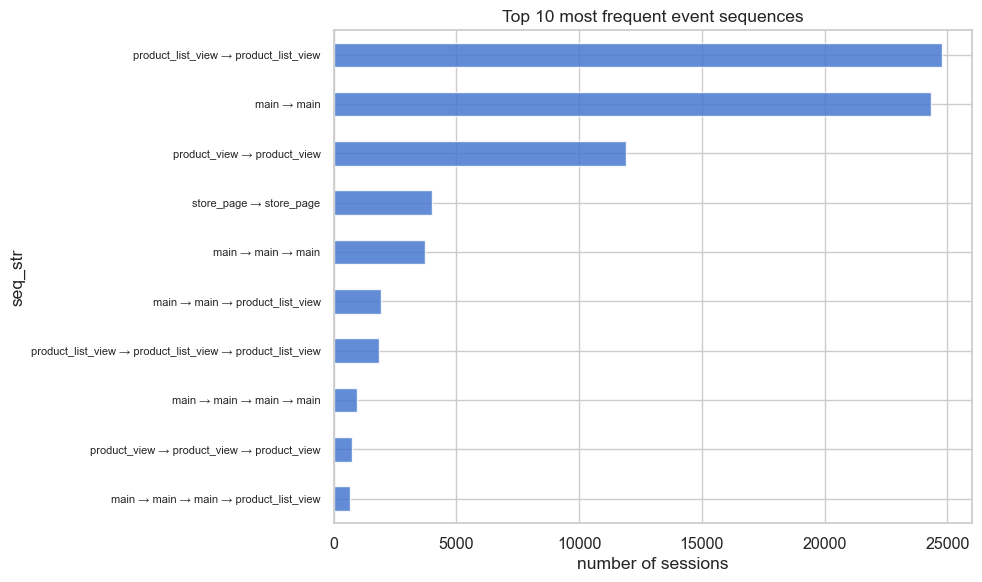

In [191]:
sequences_valid['seq_str'] = sequences_valid['event_sequence'].apply(
    lambda s: ' → '.join(s)
)

top_paths = sequences_valid['seq_str'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_paths.sort_values().plot(kind='barh', ax=ax, color='#4878CF', alpha=0.85)
ax.set_xlabel('number of sessions')
ax.set_title('Top 10 most frequent event sequences')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p7_top_sequences.png', dpi=120)
plt.show()

### 4.5 Event bigrams

For each session, extract all consecutive event pairs (A → B).
This is the foundation of the Markov transition matrix.

In [192]:
def extract_bigrams(seq):
    return list(zip(seq[:-1], seq[1:]))

bigrams_all = []
for _, row in sequences_valid.iterrows():
    for a, b in extract_bigrams(row['event_sequence']):
        bigrams_all.append({
            'from_event': a,
            'to_event': b,
            'is_old': row['is_old'],
            'category': row['category'],})

bigrams_df = pd.DataFrame(bigrams_all)
trans_counts = (
    bigrams_df.groupby(['from_event', 'to_event'])
    .size()
    .unstack(fill_value=0)
)

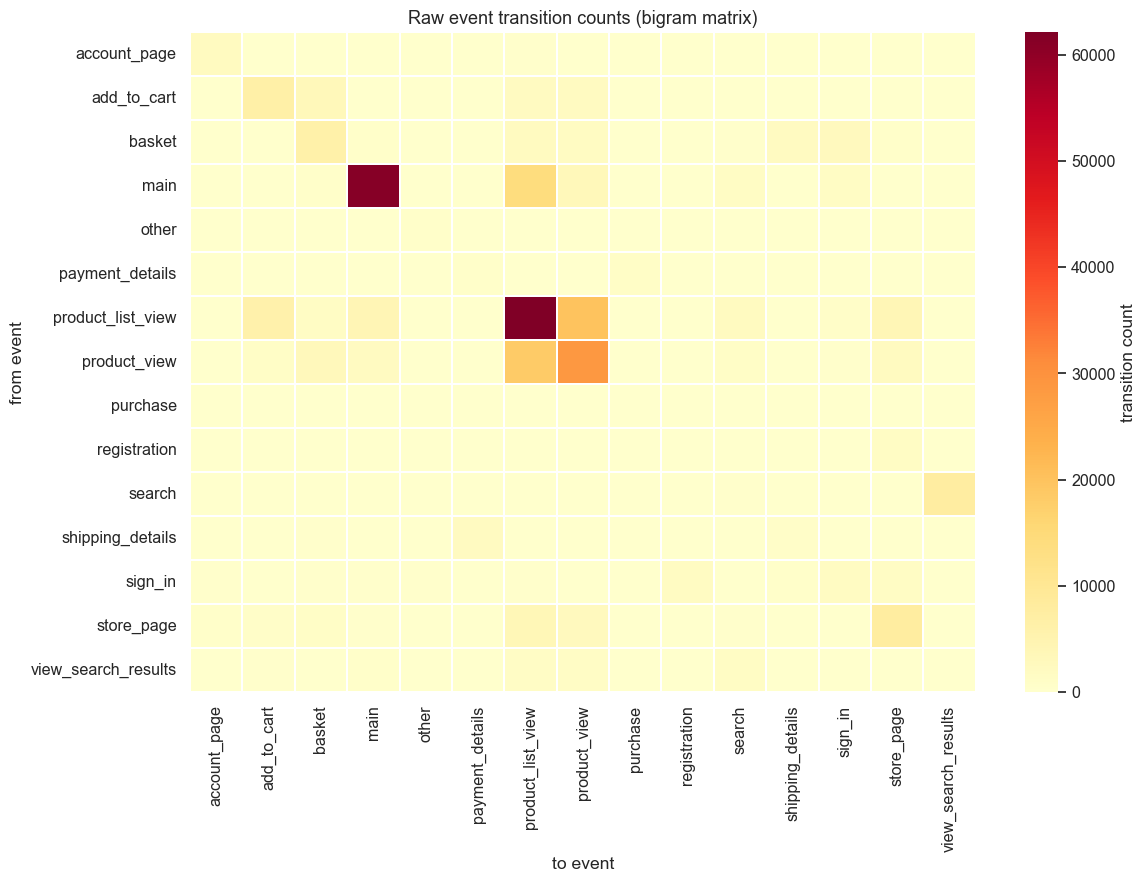

In [193]:
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(trans_counts, cmap='YlOrRd', annot=False,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'transition count'}, ax=ax)
ax.set_title('Raw event transition counts (bigram matrix)', fontsize=13)
ax.set_xlabel('to event')
ax.set_ylabel('from event')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p7_bigram_counts.png', dpi=120)
plt.show()

### 4.6 Self-loops and diagonal dominance

In [194]:
total_bigrams = len(bigrams_df)
self_bigrams  = (bigrams_df['from_event'] == bigrams_df['to_event']).sum()

print(f"Total bigrams: {total_bigrams:,}")
print(f"Self-loop bigrams: {self_bigrams:,} ({self_bigrams/total_bigrams*100:.1f}%)")

pure_self = sequences_valid['event_sequence'].apply(lambda s: len(set(s)) == 1).sum()
print(f"\nSessions with only one unique event: {pure_self:,} "
      f"({pure_self/len(sequences_valid)*100:.1f}%)")

Total bigrams: 323,968
Self-loop bigrams: 179,586 (55.4%)

Sessions with only one unique event: 74,903 (72.0%)


42% of raw bigrams are self-transitions (A → A). Analysis shows these originate
primarily from bounce sessions of length 2 (65,792 sessions) where the tracker
registers the same event twice — not a real navigation decision.

Rather than collapsing sequences, we exclude self-loop bigrams directly from the
transition matrix. This preserves the original sequences intact while modeling
only meaningful state changes.

In [195]:
bigrams_df = bigrams_df[bigrams_df['from_event'] != bigrams_df['to_event']]